## Assignment 2: $k$ Nearest Neighbor

### Do any four.

In [1]:
! git clone https://github.com/ds4e/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 115, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 115 (delta 40), reused 31 (delta 30), pack-reused 65 (from 2)
Receiving objects: 100% (115/115), 1.73 MiB | 12.58 MiB/s, done.
Resolving deltas: 100% (53/53), done.
Download complete
Extracting data files...
Data extracted


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, mean_squared_error, ConfusionMatrixDisplay

def maxmin(s):
    return (s - s.min()) / (s.max() - s.min())

np.random.seed(42)

**Q1.** Please answer the following questions.
1. Difference between regression and classification?

Regression predicts a number, like a house price or temperature. Classification predicts a category, like what type of mine something is or whether an email is spam.

2. What is a confusion matrix?

It's a table that shows you where your model got things right and wrong. The rows are the actual classes and the columns are what the model predicted, so you can see exactly which classes are getting mixed up rather than just knowing the overall accuracy.

3. What is Accuracy and why is it insufficient?

Accuracy is just the percentage of correct predictions. The problem is it can be misleading — if 95% of your data is class A, a model that always guesses A looks great on paper but is actually useless for detecting anything else.

4. What does RMSE quantify?

RMSE tells you how far off your predictions are on average, in the same units as whatever you're predicting. It punishes big errors more than small ones because the errors get squared before averaging.

5. What are overfitting and underfitting?

Overfitting is when your model memorizes the training data too well, including all the noise, so it falls apart on new data. Underfitting is when your model is too simple and misses the real patterns entirely. With kNN, a very small k overfits and a very large k underfits.

6. Why does a train/test split help choose k?

If you pick k using the same data you trained on, you could just use k=1 and get perfect training accuracy, but it would be useless on new data. Testing on data gives you an honest picture of how the model actually performs on something it hasn't seen before.

7. Class label vs. probability distribution?

A class label is straightforward cause you get one answer. But it hides how confident the model actually was. A probability distribution shows you that confidence, which matters a lot in situations where being wrong is costly. The downside is it's harder to act on than a simple label.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?

The model gets about 44% accuracy which isn't great but it's better than randomly guessing (which would only get you 20%). Types 1 and 2 get identified pretty well but the model really struggles with types 3, 4 and 5, mostly mixing them up with types 1 and 2. They probably just look too similar based on the features we have.

5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

I wouldn't rely on this model alone given how often it gets things wrong. It's useful for narrowing down what type of mine you might be dealing with but you shouldn't use it to make a final call. You should also look at the probabilities not just the predicted label — there's a big difference between the model being 90% sure vs 55% sure. And since some mix-ups between mine types could be deadly, when the model is uncertain you should always assume the worst and treat it as the more dangerous type.

In [3]:
# 1
mines = pd.read_csv('./data/land_mines.csv')
print('Shape:', mines.shape)
print()
print('Class distribution:')
print(mines['mine_type'].value_counts().sort_index())
print()
print(mines.describe())

Shape: (338, 4)

Class distribution:
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64

          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000


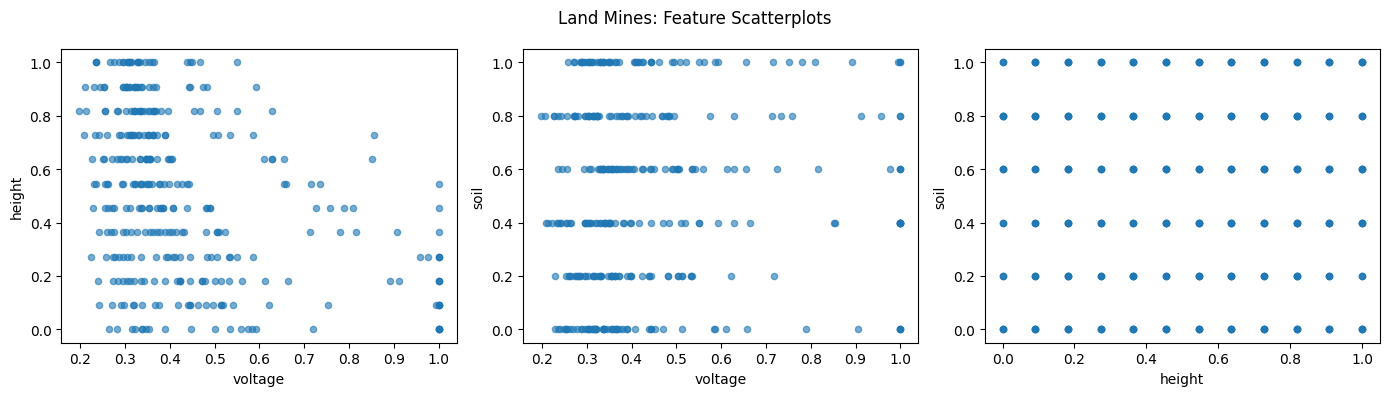

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
pairs = [('voltage','height'), ('voltage','soil'), ('height','soil')]
for ax, (x, y) in zip(axes, pairs):
    ax.scatter(mines[x], mines[y], alpha=0.6, s=20)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
plt.suptitle('Land Mines: Feature Scatterplots')
plt.tight_layout()
plt.show()

In [5]:
# 2
X_m = mines[['voltage', 'height', 'soil']]
y_m = mines['mine_type']
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_m, y_m, test_size=0.5, random_state=42, stratify=y_m
)
print(f'Train: {len(X_train_m)}, Test: {len(X_test_m)}')

Train: 169, Test: 169


Best k = 2, Accuracy = 0.4379


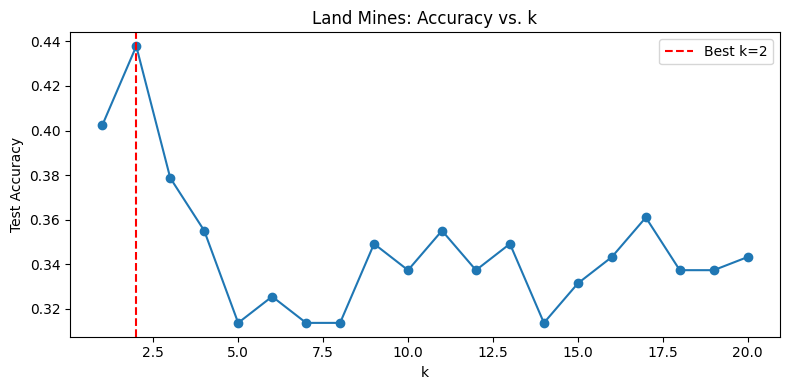

In [6]:
# 3
k_vals = range(1, 21)
accs = []
for k in k_vals:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_m, y_train_m)
    accs.append(accuracy_score(y_test_m, knn.predict(X_test_m)))

best_k_m = list(k_vals)[np.argmax(accs)]
print(f'Best k = {best_k_m}, Accuracy = {max(accs):.4f}')

plt.figure(figsize=(8, 4))
plt.plot(k_vals, accs, marker='o')
plt.axvline(best_k_m, color='red', linestyle='--', label=f'Best k={best_k_m}')
plt.xlabel('k'); plt.ylabel('Test Accuracy')
plt.title('Land Mines: Accuracy vs. k')
plt.legend(); plt.tight_layout(); plt.show()

Confusion Matrix (rows=actual, cols=predicted):
[[25  0  6  4  1]
 [ 0 32  0  3  0]
 [12  2  9  6  4]
 [12  5  8  8  0]
 [15  2 10  5  0]]

Overall Accuracy: 0.4379


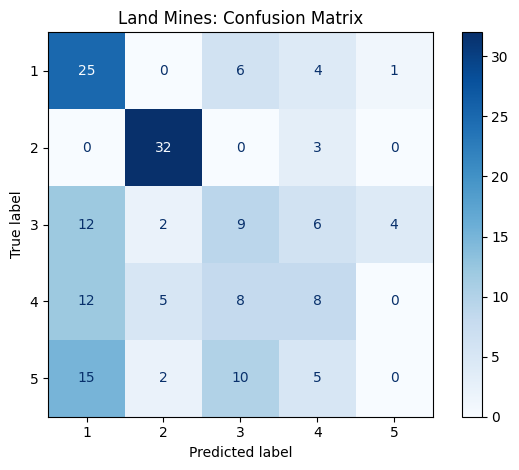

Mine type 1: 25/36 correct (69.4%)
Mine type 2: 32/35 correct (91.4%)
Mine type 3: 9/33 correct (27.3%)
Mine type 4: 8/33 correct (24.2%)
Mine type 5: 0/32 correct (0.0%)


In [7]:
# 4
knn_m = KNeighborsClassifier(n_neighbors=best_k_m)
knn_m.fit(X_train_m, y_train_m)
y_pred_m = knn_m.predict(X_test_m)

cm_m = confusion_matrix(y_test_m, y_pred_m)
print('Confusion Matrix (rows=actual, cols=predicted):')
print(cm_m)
print(f'\nOverall Accuracy: {accuracy_score(y_test_m, y_pred_m):.4f}')

disp = ConfusionMatrixDisplay(cm_m, display_labels=[1,2,3,4,5])
disp.plot(cmap='Blues')
plt.title('Land Mines: Confusion Matrix')
plt.tight_layout(); plt.show()

for i, mt in enumerate([1,2,3,4,5]):
    correct = cm_m[i, i]
    total = cm_m[i].sum()
    print(f'Mine type {mt}: {correct}/{total} correct ({100*correct/total:.1f}%)')

**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

At small k like k=3 the model overfits, it's reacting too much to individual points in the training data so the predictions are all over the place and RMSE is high.
As k gets closer to the optimal (around 49) the predictions start to smooth out and actually follow the real values more closely, you can see the points tightening around the diagonal line and RMSE drops.
At very large k like k=300 the model underfits, it's averaging over so many neighbors that it basically just predicts the same value for everything regardless of the input, the scatter plot ends up looking like a flat horizontal band and RMSE goes back up.
The best k sits in the sweet spot where it's not overreacting to noise but also not ignoring real patterns in the data.

In [8]:
# 1
cars = pd.read_csv('./data/USA_cars_datasets.csv')
cars = cars[['price', 'year', 'mileage']].dropna()
print('Shape:', cars.shape)
print('NAs:', cars.isnull().sum().to_dict())
print()
print(cars.head())
print()
print(cars.describe())

Shape: (2499, 3)
NAs: {'price': 0, 'year': 0, 'mileage': 0}

   price  year  mileage
0   6300  2008   274117
1   2899  2011   190552
2   5350  2018    39590
3  25000  2014    64146
4  27700  2018     6654

              price         year       mileage
count   2499.000000  2499.000000  2.499000e+03
mean   18767.671469  2016.714286  5.229869e+04
std    12116.094936     3.442656  5.970552e+04
min        0.000000  1973.000000  0.000000e+00
25%    10200.000000  2016.000000  2.146650e+04
50%    16900.000000  2018.000000  3.536500e+04
75%    25555.500000  2019.000000  6.347250e+04
max    84900.000000  2020.000000  1.017936e+06


In [9]:
# 2
cars['year_n']    = maxmin(cars['year'])
cars['mileage_n'] = maxmin(cars['mileage'])

# 3. 80/20 train/test split
X_c = cars[['year_n', 'mileage_n']]
y_c = cars['price']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42
)
print(f'Train: {len(X_train_c)}, Test: {len(X_test_c)}')

Train: 1999, Test: 500


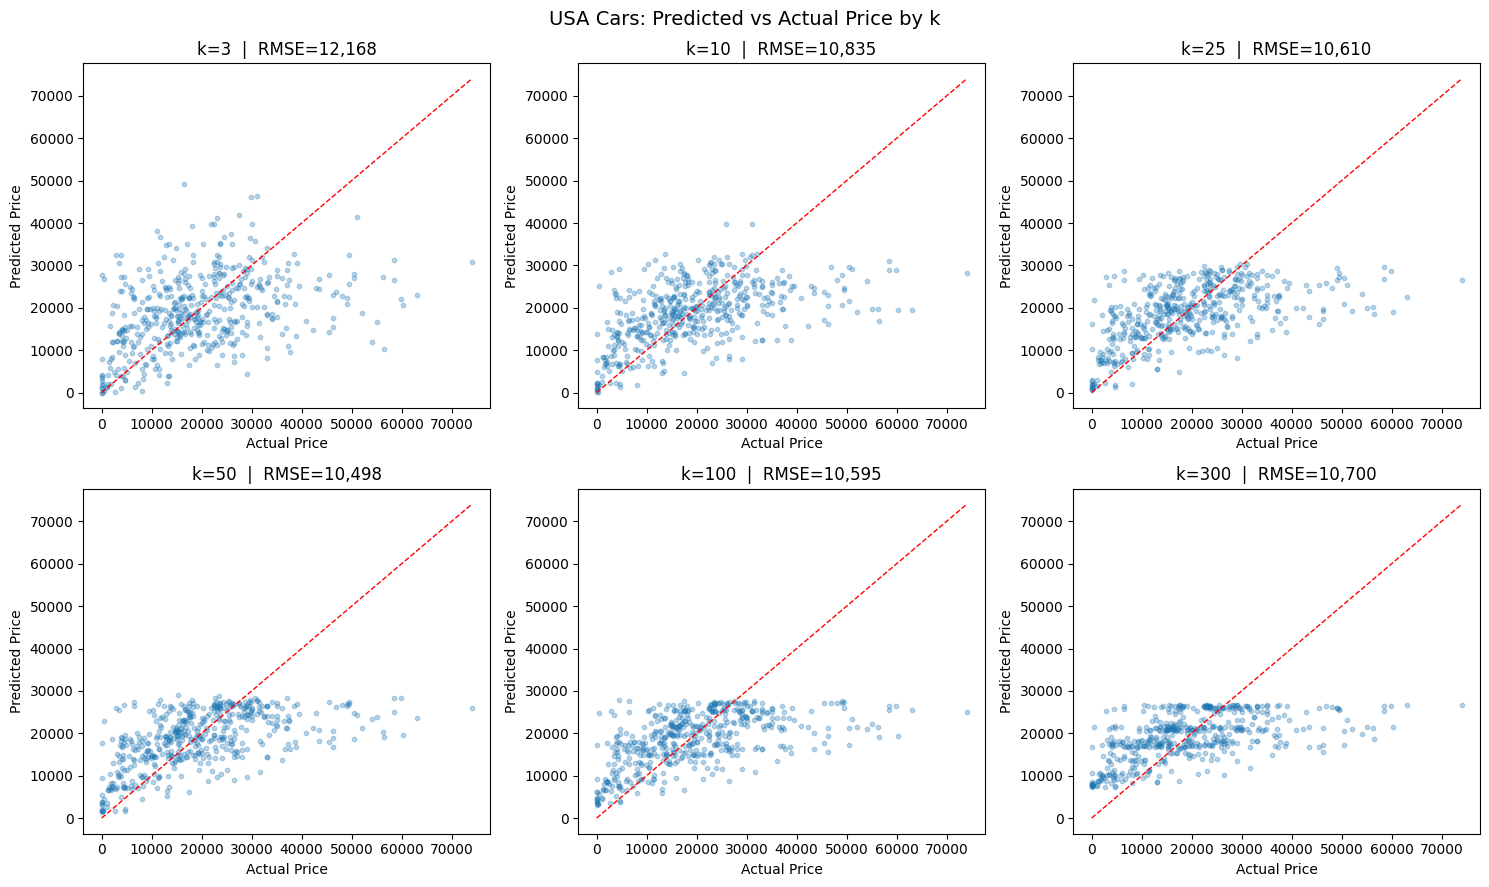

RMSE by k:
  k=   3: RMSE = 12,168.23
  k=  10: RMSE = 10,835.09
  k=  25: RMSE = 10,610.19
  k=  50: RMSE = 10,497.74
  k= 100: RMSE = 10,595.00
  k= 300: RMSE = 10,700.29


In [10]:
# 4
k_list = [3, 10, 25, 50, 100, 300]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
rmse_results = {}

for ax, k in zip(axes.flatten(), k_list):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_c, y_train_c)
    preds = knn.predict(X_test_c)
    rmse = np.sqrt(mean_squared_error(y_test_c, preds))
    rmse_results[k] = rmse
    ax.scatter(y_test_c, preds, alpha=0.3, s=10)
    ax.plot([0, y_test_c.max()], [0, y_test_c.max()], 'r--', lw=1)
    ax.set_xlabel('Actual Price'); ax.set_ylabel('Predicted Price')
    ax.set_title(f'k={k}  |  RMSE={rmse:,.0f}')

plt.suptitle('USA Cars: Predicted vs Actual Price by k', fontsize=14)
plt.tight_layout(); plt.show()

print('RMSE by k:')
for k, r in rmse_results.items():
    print(f'  k={k:>4}: RMSE = {r:,.2f}')

Optimal k = 49, RMSE = 10,484.81


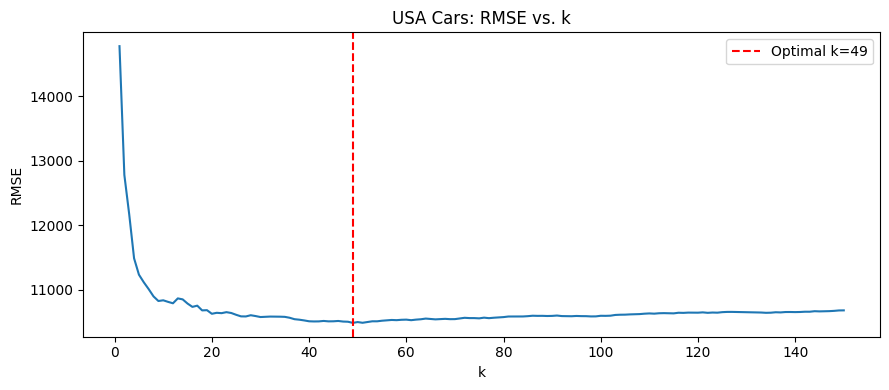

In [11]:
# 5
ks = range(1, 151)
rmses = []
for k in ks:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_c, y_train_c)
    rmses.append(np.sqrt(mean_squared_error(y_test_c, knn.predict(X_test_c))))

best_k_c = list(ks)[np.argmin(rmses)]
print(f'Optimal k = {best_k_c}, RMSE = {min(rmses):,.2f}')

plt.figure(figsize=(9, 4))
plt.plot(ks, rmses)
plt.axvline(best_k_c, color='red', linestyle='--', label=f'Optimal k={best_k_c}')
plt.xlabel('k'); plt.ylabel('RMSE')
plt.title('USA Cars: RMSE vs. k')
plt.legend(); plt.tight_layout(); plt.show()

**Q4.** This question is a case study for $k$ nearest neighbor regression, using the `heart_failure_clinical_records_dataset.csv` data.

The data for the question include:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- high blood pressure: if the patient has hypertension (boolean)
- creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- death event: if the patient deceased during the follow-up period (boolean)

1. Load the `./data/heart_failure_clinical_records_dataset.csv`. Are there any `NA`'s to handle? use `.drop()` to remove `time` from the dataframe.
2. Make a correlation matrix. What variables are strongly associated with a death event?
3. For the dummy variables `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, and `smoking`, compute a summary table of `DEATH_EVENT` grouped by the variable. For which variables does a higher proportion of the population die when the variable takes the value 1 rather than 0?
4. On the basis of your answers from 2 and 3, build a matrix $X$ of the variables you think are most predictive of a death, and a variable $y$ equal to `DEATH_EVENT`.
5. Maxmin normalize all of the variables in `X`.
6. Split the sample into ~80% for training and ~20% for evaluation. (Try to use the same train/test split for the whole question, so that you're comparing apples to apples in the questions below.).
7. Determine the optimal number of neighbors for a $k$-NN classification or regression for the variables you selected.
8. OK, do steps 5 through 7 again, but use all of the variables (except `time`). Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict `DEATH_EVENT`s? If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.

**Q5.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on.

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion matrix for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?
5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying proportions/probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.

**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings.
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

In [12]:
# 1
airbnb = pd.read_csv('./data/airbnb_hw.csv')
airbnb = airbnb.loc[:, ['Review Scores Rating', 'Price', 'Beds']]
airbnb['Price'] = pd.to_numeric(
    airbnb['Price'].astype(str).str.replace(r'[^\d.]', '', regex=True),
    errors='coerce'
)
print('Shape:', airbnb.shape)
print('NAs:', airbnb.isnull().sum().to_dict())

Shape: (30478, 3)
NAs: {'Review Scores Rating': 8323, 'Price': 0, 'Beds': 85}


In [13]:
# 2
missing_reviews = airbnb[airbnb['Review Scores Rating'].isnull()].copy()
print(f'Missing ratings: {len(missing_reviews)}')

Missing ratings: 8323


In [14]:
# 3
df = airbnb.dropna(axis=0, how='any').copy()
print(f'Complete cases: {len(df)}')

Complete cases: 22111


Optimal k = 49, RMSE = 8.5257


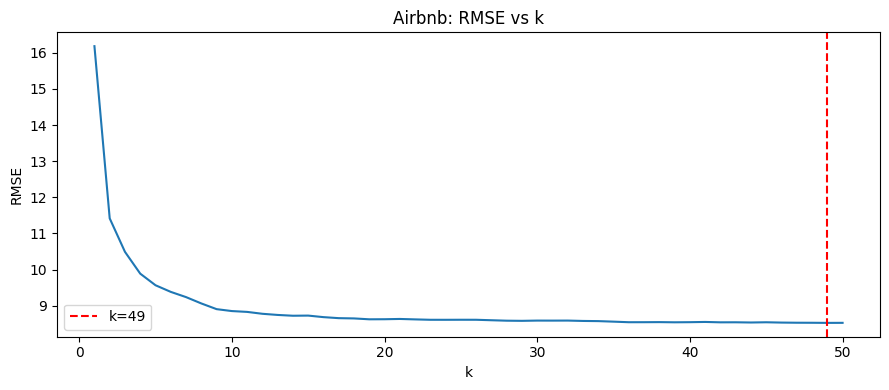

In [15]:
# 4
price_min, price_max = df['Price'].min(), df['Price'].max()
beds_min,  beds_max  = df['Beds'].min(),  df['Beds'].max()

df['Price_n'] = (df['Price'] - price_min) / (price_max - price_min)
df['Beds_n']  = (df['Beds']  - beds_min)  / (beds_max  - beds_min)

X_air = df[['Price_n', 'Beds_n']]
y_air = df['Review Scores Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X_air, y_air, test_size=0.2, random_state=42
)

ks = range(1, 51)
rmses = []
for k in ks:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    rmses.append(np.sqrt(mean_squared_error(y_test, knn.predict(X_test))))

best_k = list(ks)[np.argmin(rmses)]
print(f'Optimal k = {best_k}, RMSE = {min(rmses):.4f}')

plt.figure(figsize=(9, 4))
plt.plot(ks, rmses)
plt.axvline(best_k, color='red', linestyle='--', label=f'k={best_k}')
plt.xlabel('k'); plt.ylabel('RMSE')
plt.title('Airbnb: RMSE vs k')
plt.legend(); plt.tight_layout(); plt.show()

In [16]:
# 5
knn_final = KNeighborsRegressor(n_neighbors=best_k)
knn_final.fit(X_train, y_train)

to_predict = missing_reviews.dropna(subset=['Price', 'Beds']).copy()
to_predict['Price_n'] = (to_predict['Price'] - price_min) / (price_max - price_min)
to_predict['Beds_n']  = (to_predict['Beds']  - beds_min)  / (beds_max  - beds_min)

imputed = knn_final.predict(to_predict[['Price_n', 'Beds_n']])
print(f'Imputed {len(imputed)} missing ratings')
print(f'Imputed mean: {imputed.mean():.2f}, std: {imputed.std():.2f}')
print(f'Actual  mean: {y_air.mean():.2f}, std: {y_air.std():.2f}')

Imputed 8282 missing ratings
Imputed mean: 92.10, std: 2.32
Actual  mean: 91.99, std: 8.85


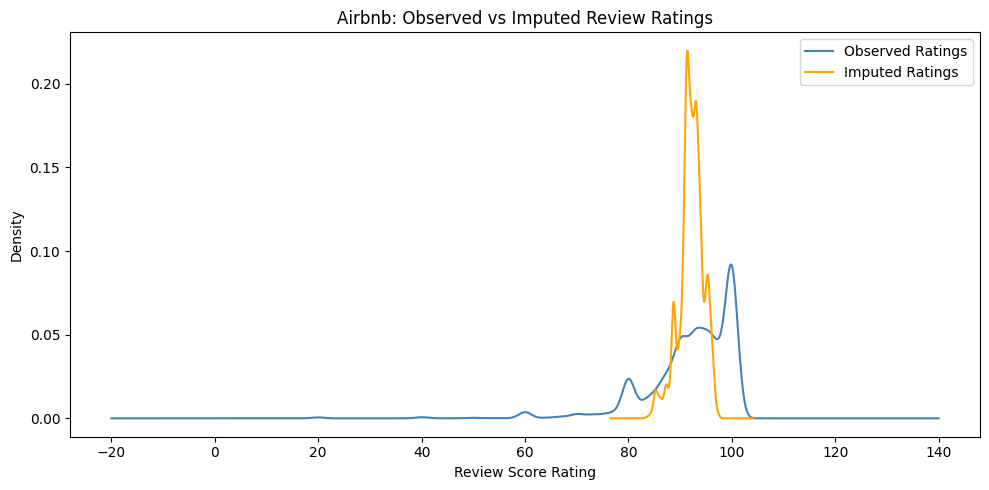

In [17]:
# 6
fig, ax = plt.subplots(figsize=(10, 5))
y_air.plot.kde(ax=ax, label='Observed Ratings', color='steelblue')
pd.Series(imputed).plot.kde(ax=ax, label='Imputed Ratings', color='orange')
ax.set_xlabel('Review Score Rating')
ax.set_title('Airbnb: Observed vs Imputed Review Ratings')
ax.legend(); plt.tight_layout(); plt.show()

**Q7.** Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and use $k$-NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5):
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a list of matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)